<a href="https://colab.research.google.com/github/HarshMurarka28/PINN/blob/main/Bendingtheory_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyDOE

In [ ]:
"""
Physics-Informed Neural Network (PINN) for Kirchhoff Plate Bending
===================================================================
PDE:  ∇⁴w = q/D
      w_xxxx + 2*w_xxyy + w_yyyy = q(x,y) / D

Problem : Simply-supported square plate, uniform load q₀
Domain  : x ∈ [0, a],  y ∈ [0, b]

Boundary conditions (simply supported on all 4 edges):
  w    = 0  on all edges          (zero deflection)
  w_xx = 0  on x=0 and x=a       (zero moment Mx)
  w_yy = 0  on y=0 and y=b       (zero moment My)

Validation: Navier double-sine series (exact closed-form solution)

Install:
    pip install tensorflow numpy matplotlib scipy pyDOE
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pyDOE import lhs
from scipy.optimize import minimize


# ═════════════════════════════════════════════════════════════════════════════
# 1.  Neural Network Architecture
# ═════════════════════════════════════════════════════════════════════════════
class PINN(tf.keras.Model):
    """
    CHANGES FROM BURGERS:
      - Input is now (x, y) instead of (t, x)  — still 2 features, no change needed
      - Network is wider/deeper: 6 hidden layers × 40 neurons
        because the biharmonic operator is 4th-order and needs more capacity
      - Everything else (tanh, glorot_normal, no output activation) stays the same
    """

    def __init__(self, layers):
        super().__init__()
        self.hidden_layers = []
        for width in layers[1:-1]:
            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    width,
                    activation="tanh",
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                )
            )
        self.out_layer = tf.keras.layers.Dense(
            layers[-1],
            kernel_initializer="glorot_normal",
            bias_initializer="zeros",
        )

    def call(self, x, y):
        """
        CHANGE: arguments renamed from (t, x) → (x, y)
        Everything else identical.
        """
        inputs = tf.concat([x, y], axis=1)   # (N, 2)
        z = inputs
        for layer in self.hidden_layers:
            z = layer(z)
        return self.out_layer(z)             # (N, 1)  — predicts w(x, y)


# ═════════════════════════════════════════════════════════════════════════════
# 2.  Physics Residual
# ═════════════════════════════════════════════════════════════════════════════
def plate_residual(model, x_f, y_f, q0, D):
    """
    REPLACES: burgers_residual()

    Computes the biharmonic residual:
        f = w_xxxx + 2*w_xxyy + w_yyyy  -  q/D

    KEY DIFFERENCE from Burgers:
      Burgers needed 2 levels of GradientTape (for u_xx).
      The biharmonic needs 4 levels — we nest 4 tapes.
      Each inner tape must watch the variables of the tape above it,
      and persistent=True is needed whenever we differentiate the same
      tensor more than once (e.g. w_x w.r.t. x AND w_y w.r.t. y).

    Returns:
      f       — PDE residual (should be 0 everywhere inside domain)
      w_xx    — needed for moment BC on x-edges
      w_yy    — needed for moment BC on y-edges
    """
    with tf.GradientTape(persistent=True) as tape4:
        tape4.watch([x_f, y_f])
        with tf.GradientTape(persistent=True) as tape3:
            tape3.watch([x_f, y_f])
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch([x_f, y_f])
                with tf.GradientTape(persistent=True) as tape1:
                    tape1.watch([x_f, y_f])

                    w = model(x_f, y_f)          # forward pass → w(x,y)

                # ── First derivatives ─────────────────────────────────
                w_x = tape1.gradient(w,   x_f)  # ∂w/∂x
                w_y = tape1.gradient(w,   y_f)  # ∂w/∂y

            # ── Second derivatives ────────────────────────────────────
            w_xx = tape2.gradient(w_x, x_f)     # ∂²w/∂x²
            w_yy = tape2.gradient(w_y, y_f)     # ∂²w/∂y²
            w_xy = tape2.gradient(w_x, y_f)     # ∂²w/∂x∂y  (not used in residual
                                                 #            but available for Mxy)

        # ── Third derivatives ─────────────────────────────────────────
        w_xxx = tape3.gradient(w_xx, x_f)       # ∂³w/∂x³
        w_xxy = tape3.gradient(w_xx, y_f)       # ∂³w/∂x²∂y
        w_yyy = tape3.gradient(w_yy, y_f)       # ∂³w/∂y³

    # ── Fourth derivatives ────────────────────────────────────────────
    w_xxxx = tape4.gradient(w_xxx, x_f)         # ∂⁴w/∂x⁴
    w_xxyy = tape4.gradient(w_xxy, y_f)         # ∂⁴w/∂x²∂y²
    w_yyyy = tape4.gradient(w_yyy, y_f)         # ∂⁴w/∂y⁴

    del tape1, tape2, tape3, tape4

    # Uniform load — replace with q(x_f, y_f) for a varying load
    q = q0 * tf.ones_like(w)

    # Biharmonic residual
    f = w_xxxx + 2.0 * w_xxyy + w_yyyy - q / D

    return f, w_xx, w_yy    # w_xx and w_yy returned for moment BCs


# ═════════════════════════════════════════════════════════════════════════════
# 3.  Loss Function
# ═════════════════════════════════════════════════════════════════════════════
def compute_loss(model, x_f, y_f, x_x0, y_x0, x_xa, y_xa,
                 x_y0, y_y0, x_yb, y_yb, q0, D,
                 lam_w=10.0, lam_m=10.0):

    # ── PDE residual + moment BCs for interior (one tape call) ──
    f, w_xx_f, w_yy_f = plate_residual(model, x_f, y_f, q0, D)
    mse_f = tf.reduce_mean(tf.square(f))

    # ── Deflection BC: w = 0 on all edges ──
    w_x0 = model(x_x0, y_x0)
    w_xa = model(x_xa, y_xa)
    w_y0 = model(x_y0, y_y0)
    w_yb = model(x_yb, y_yb)
    mse_w = (tf.reduce_mean(tf.square(w_x0)) +
             tf.reduce_mean(tf.square(w_xa)) +
             tf.reduce_mean(tf.square(w_y0)) +
             tf.reduce_mean(tf.square(w_yb)))

    # ── Moment BCs: compute w_xx and w_yy directly (2 tapes only) ──
    def get_second_derivs(x_b, y_b):
        with tf.GradientTape(persistent=True) as t2:
            t2.watch([x_b, y_b])
            with tf.GradientTape(persistent=True) as t1:
                t1.watch([x_b, y_b])
                w = model(x_b, y_b)
            w_x = t1.gradient(w, x_b)
            w_y = t1.gradient(w, y_b)
            del t1
        w_xx = t2.gradient(w_x, x_b)
        w_yy = t2.gradient(w_y, y_b)
        del t2
        return w_xx, w_yy

    w_xx_x0, _       = get_second_derivs(x_x0, y_x0)
    w_xx_xa, _       = get_second_derivs(x_xa, y_xa)
    _,       w_yy_y0 = get_second_derivs(x_y0, y_y0)
    _,       w_yy_yb = get_second_derivs(x_yb, y_yb)

    mse_m = (tf.reduce_mean(tf.square(w_xx_x0)) +
             tf.reduce_mean(tf.square(w_xx_xa)) +
             tf.reduce_mean(tf.square(w_yy_y0)) +
             tf.reduce_mean(tf.square(w_yy_yb)))

    total = mse_f + lam_w * mse_w + lam_m * mse_m
    return total, mse_f, mse_w, mse_m
# ═════════════════════════════════════════════════════════════════════════════
# 4.  Training Data Generation
# ═════════════════════════════════════════════════════════════════════════════
def generate_training_data(a=1.0, b=1.0, Nf=10_000, Nb=200):
    """
    REPLACES: generate_training_data() for Burgers

    CHANGES:
      - Domain is now [0,a] × [0,b] instead of [0,1] × [-1,1]
      - No IC/BC data points with known u values (X_u, U_u removed)
      - Instead: boundary points separated per edge so each BC can be
        applied differently in the loss function
      - Nb points sampled on EACH of the 4 edges (4*Nb total boundary pts)
    """
    lb = np.array([0.0, 0.0])
    ub = np.array([a,   b  ])

    # ── Interior collocation points (LHS) ────────────────────────────────
    X_f = lb + (ub - lb) * lhs(2, Nf)    # shape (Nf, 2)

    # ── Boundary points — one set per edge ───────────────────────────────
    s = np.random.uniform   # shorthand

    # x = 0  (left edge)
    X_x0 = np.hstack([np.zeros((Nb, 1)),        s(0, b, (Nb, 1))])

    # x = a  (right edge)
    X_xa = np.hstack([a * np.ones((Nb, 1)),     s(0, b, (Nb, 1))])

    # y = 0  (bottom edge)
    X_y0 = np.hstack([s(0, a, (Nb, 1)),         np.zeros((Nb, 1))])

    # y = b  (top edge)
    X_yb = np.hstack([s(0, a, (Nb, 1)),         b * np.ones((Nb, 1))])

    return X_f, X_x0, X_xa, X_y0, X_yb


def to_tf(arr):
    return tf.constant(arr, dtype=tf.float32)


# ═════════════════════════════════════════════════════════════════════════════
# 5.  L-BFGS Trainer
# ═════════════════════════════════════════════════════════════════════════════
class LBFGSTrainer:
    """
    CHANGES FROM BURGERS VERSION:
      - Constructor receives per-edge boundary tensors instead of t_u/x_u/u_u
      - loss_and_grad() calls compute_loss() with the new plate signature
      - Prints 4 loss components instead of 2
      - Everything else (pack/unpack, scipy.minimize call) is identical
    """

    def __init__(self, model,
                 x_f,  y_f,
                 x_x0, y_x0,
                 x_xa, y_xa,
                 x_y0, y_y0,
                 x_yb, y_yb,
                 q0, D):
        self.model = model
        # Store all tensors
        self.x_f,  self.y_f   = x_f,  y_f
        self.x_x0, self.y_x0  = x_x0, y_x0
        self.x_xa, self.y_xa  = x_xa, y_xa
        self.x_y0, self.y_y0  = x_y0, y_y0
        self.x_yb, self.y_yb  = x_yb, y_yb
        self.q0, self.D       = q0, D

        self.iter         = 0
        self.loss_history = []
        self.shapes       = [v.shape for v in model.trainable_variables]
        self.n_params     = sum(np.prod(s) for s in self.shapes)
        print(f"Total trainable parameters: {self.n_params}")

    def _pack(self):
        return np.concatenate(
            [v.numpy().flatten() for v in self.model.trainable_variables]
        )

    def _unpack(self, flat):
        offset = 0
        for var, shape in zip(self.model.trainable_variables, self.shapes):
            size = np.prod(shape)
            var.assign(flat[offset: offset + size].reshape(shape))
            offset += size

    def loss_and_grad(self, flat_params):
        self._unpack(flat_params)

        with tf.GradientTape() as tape:
            loss, mse_f, mse_w, mse_m = compute_loss(
                self.model,
                self.x_f,  self.y_f,
                self.x_x0, self.y_x0,
                self.x_xa, self.y_xa,
                self.x_y0, self.y_y0,
                self.x_yb, self.y_yb,
                self.q0, self.D
            )

        grads     = tape.gradient(loss, self.model.trainable_variables)
        flat_grad = np.concatenate([g.numpy().flatten() for g in grads])

        loss_val  = loss.numpy().astype(np.float64)
        self.iter += 1

        if self.iter % 500 == 0:
            print(f"  Iter {self.iter:6d} | Loss {loss_val:.3e} | "
                  f"PDE {mse_f.numpy():.3e} | "
                  f"w-BC {mse_w.numpy():.3e} | "
                  f"M-BC {mse_m.numpy():.3e}")
            self.loss_history.append(loss_val)

        return loss_val, flat_grad.astype(np.float64)

    def train(self, max_iter=50_000):
        print("\nTraining with L-BFGS-B ...")
        x0     = self._pack().astype(np.float64)
        result = minimize(
            self.loss_and_grad, x0,
            method="L-BFGS-B", jac=True,
            options={"maxiter": max_iter, "maxfun": max_iter,
                     "ftol": 1e-12, "gtol": 1e-8, "disp": False},
        )
        self._unpack(result.x)
        print(f"Finished — {result.message}")
        print(f"Final loss: {result.fun:.3e}\n")
        return self.loss_history


# ═════════════════════════════════════════════════════════════════════════════
# 6.  Exact Navier Solution  (replaces pseudo-spectral Burgers reference)
# ═════════════════════════════════════════════════════════════════════════════
def navier_solution(X, Y, a, b, D, q0, n_terms=49):
    """
    REPLACES: compute_reference()

    Exact closed-form Navier series for a simply-supported plate:

        w(x,y) = (16*q0) / (π⁶ * D)
                 × ΣΣ  sin(mπx/a) * sin(nπy/b)
                        ────────────────────────────
                        m*n * (m²/a² + n²/b²)²

    where m, n run over odd integers 1, 3, 5, ...

    Converges very fast — 49 terms (m,n up to 7×7 odd) gives <0.01% error.
    """
    w = np.zeros_like(X, dtype=float)
    for m in range(1, n_terms + 1, 2):          # odd m: 1,3,5,...
        for n in range(1, n_terms + 1, 2):      # odd n: 1,3,5,...
            coeff = 16.0 * q0 / (np.pi**6 * D * m * n)
            denom = (m**2 / a**2 + n**2 / b**2) ** 2
            w += coeff / denom * \
                 np.sin(m * np.pi * X / a) * \
                 np.sin(n * np.pi * Y / b)
    return w


# ═════════════════════════════════════════════════════════════════════════════
# 7.  Evaluation & Plotting
# ═════════════════════════════════════════════════════════════════════════════
def evaluate_and_plot(model, loss_history, a, b, D, q0):
    """
    REPLACES: evaluate_and_plot() for Burgers

    CHANGES:
      - Evaluation grid is (x,y) over [0,a]×[0,b] instead of (t,x)
      - Reference is Navier series instead of spectral PDE solver
      - Plots: PINN contour | Exact contour | Error contour | centre-line slice
    """
    N      = 100
    x_vals = np.linspace(0, a, N)
    y_vals = np.linspace(0, b, N)
    X, Y   = np.meshgrid(x_vals, y_vals)        # both (N, N)

    x_flat = to_tf(X.flatten()[:, None])
    y_flat = to_tf(Y.flatten()[:, None])

    w_pred  = model(x_flat, y_flat).numpy().reshape(N, N)
    w_exact = navier_solution(X, Y, a, b, D, q0)

    # ── Metrics ──────────────────────────────────────────────────────────
    rel_l2   = (np.linalg.norm(w_pred - w_exact) /
                np.linalg.norm(w_exact))
    w_c_pred  = w_pred[N//2, N//2]
    w_c_exact = w_exact[N//2, N//2]
    print(f"Relative L2 error        : {rel_l2:.3e}")
    print(f"Centre deflection — PINN : {w_c_pred:.4e} m")
    print(f"Centre deflection — Exact: {w_c_exact:.4e} m")

    # ── Figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(
        r"PINN — Kirchhoff Plate Bending   $\nabla^4 w = q/D$"
        f"\nRel. L² error = {rel_l2:.2e}   |   "
        f"Centre deflection = {w_c_pred:.3e} m  (Exact: {w_c_exact:.3e} m)",
        fontsize=12
    )

    # Common colormap limits
    vmin = min(w_pred.min(), w_exact.min())
    vmax = max(w_pred.max(), w_exact.max())

    # Panel 1 — PINN prediction
    ax = axes[0, 0]
    im = ax.contourf(X, Y, w_pred,  levels=40, cmap="viridis",
                     vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label="w (m)")
    ax.set_title("PINN prediction  w(x,y)")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    # Panel 2 — Navier exact solution
    ax = axes[0, 1]
    im = ax.contourf(X, Y, w_exact, levels=40, cmap="viridis",
                     vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label="w (m)")
    ax.set_title("Navier exact solution")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    # Panel 3 — Pointwise absolute error
    ax = axes[1, 0]
    err_field = np.abs(w_pred - w_exact)
    im = ax.contourf(X, Y, err_field, levels=40, cmap="Reds")
    plt.colorbar(im, ax=ax, label="|error| (m)")
    ax.set_title("Pointwise absolute error")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    # Panel 4 — Centre-line slice at y = b/2
    ax = axes[1, 1]
    mid = N // 2
    ax.plot(x_vals, w_exact[mid, :], "b-",  lw=2,   label="Exact  (Navier)")
    ax.plot(x_vals, w_pred[mid, :],  "r--", lw=1.5, label="PINN")
    ax.set_title(f"Centre-line slice  y = {b/2:.2f} m")
    ax.set_xlabel("x (m)");  ax.set_ylabel("w (m)")
    ax.legend();  ax.grid(alpha=0.3)

    plt.tight_layout()
    out = "/content/pinn_plate_bending.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Plot saved → {out}")
    plt.show()

    # ── Loss curve ────────────────────────────────────────────────────────
    if loss_history:
        fig2, ax2 = plt.subplots(figsize=(7, 4))
        ax2.semilogy(
            [i * 500 for i in range(1, len(loss_history) + 1)],
            loss_history, "b-o", ms=4
        )
        ax2.set_xlabel("Iteration");  ax2.set_ylabel("Total Loss")
        ax2.set_title("Training Loss  (L-BFGS-B)")
        ax2.grid(alpha=0.3)
        plt.savefig("/content/pinn_plate_loss.png", dpi=150, bbox_inches="tight")
        plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# 8.  Entry Point
# ═════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ── Physical parameters ───────────────────────────────────────────────
    E    = 200e9          # Young's modulus  (Pa) — structural steel
    nu   = 0.3            # Poisson's ratio
    h    = 0.01           # plate thickness  (m)
    q0   = 1e4            # uniform transverse load  (N/m²)
    a, b = 1.0, 1.0       # plate dimensions (m)
    D    = E * h**3 / (12.0 * (1.0 - nu**2))
    print(f"Flexural rigidity  D = {D:.4e}  N·m")

    # ── Build model — wider + deeper than Burgers for 4th-order PDE ───────
    # [2, 40, 40, 40, 40, 40, 40, 1]  → 6 hidden layers × 40 neurons
    layers = [2] + [40] * 6 + [1]
    model  = PINN(layers)

    # ── Generate training data ─────────────────────────────────────────────
    X_f, X_x0, X_xa, X_y0, X_yb = generate_training_data(
        a=a, b=b, Nf=10_000, Nb=200
    )

    # Convert boundary arrays to separate x and y tensors
    x_f   = to_tf(X_f[:,  0:1]);  y_f   = to_tf(X_f[:,  1:2])
    x_x0  = to_tf(X_x0[:, 0:1]); y_x0  = to_tf(X_x0[:, 1:2])
    x_xa  = to_tf(X_xa[:, 0:1]); y_xa  = to_tf(X_xa[:, 1:2])
    x_y0  = to_tf(X_y0[:, 0:1]); y_y0  = to_tf(X_y0[:, 1:2])
    x_yb  = to_tf(X_yb[:, 0:1]); y_yb  = to_tf(X_yb[:, 1:2])

    # ── Warm-up with Adam (helps L-BFGS start from a better point) ────────
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=1e-3)
    print("Warm-up with Adam (1000 steps) ...")
    for step in range(1000):
        with tf.GradientTape() as tape:
            loss, mse_f, mse_w, mse_m = compute_loss(
                model,
                x_f,  y_f,
                x_x0, y_x0,
                x_xa, y_xa,
                x_y0, y_y0,
                x_yb, y_yb,
                q0, D
            )
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer_adam.apply_gradients(zip(grads, model.trainable_variables))
        if (step + 1) % 200 == 0:
            print(f"  Adam step {step+1:4d} | Loss {loss.numpy():.3e} | "
                  f"PDE {mse_f.numpy():.3e} | "
                  f"w-BC {mse_w.numpy():.3e} | "
                  f"M-BC {mse_m.numpy():.3e}")

    # ── Main L-BFGS optimisation ───────────────────────────────────────────
    trainer = LBFGSTrainer(
        model,
        x_f,  y_f,
        x_x0, y_x0,
        x_xa, y_xa,
        x_y0, y_y0,
        x_yb, y_yb,
        q0, D
    )
    loss_history = trainer.train(max_iter=6_000)

    # ── Evaluate & plot ────────────────────────────────────────────────────
    evaluate_and_plot(model, loss_history, a, b, D, q0)

Flexural rigidity  D = 1.8315e+04  N·m
Warm-up with Adam (1000 steps) ...
  Adam step  200 | Loss 4.027e-02 | PDE 3.291e-02 | w-BC 4.753e-05 | M-BC 6.887e-04
  Adam step  400 | Loss 2.707e-02 | PDE 2.444e-02 | w-BC 2.224e-05 | M-BC 2.410e-04


KeyboardInterrupt: 

/tmp/ipykernel_4435/1673516932.py:32: DeprecationWarning: Importing `pyDOE` is deprecated and will be removed in a future release. Please import `pydoe` instead.
  from pyDOE import lhs


Flexural rigidity  D = 1.8315e+04  N·m

Generating warm-up data (small) ...

Verifying @tf.function compilation (first step = slow, rest = fast):
  Step 0: 16.30s  | Loss 1.618e+01
  Step 1: 0.04s  | Loss 6.274e+00
  Step 2: 0.04s  | Loss 2.277e+00
  Step 3: 0.04s  | Loss 1.848e+00
  Step 4: 0.04s  | Loss 2.620e+00
  ✓ If steps 1-4 are <0.5s, compilation is working correctly.

Adam warm-up (1000 steps, small dataset) ...
  Adam step  200 | Loss 4.294e-02 | PDE 3.406e-02 | w-BC 4.535e-05 | M-BC 8.432e-04
  Adam step  400 | Loss 3.419e-02 | PDE 3.003e-02 | w-BC 2.893e-05 | M-BC 3.867e-04
  Adam step  600 | Loss 2.679e-02 | PDE 2.386e-02 | w-BC 3.915e-05 | M-BC 2.534e-04
  Adam step  800 | Loss 1.781e-02 | PDE 1.553e-02 | w-BC 3.381e-05 | M-BC 1.940e-04
  Adam step 1000 | Loss 8.970e-03 | PDE 7.153e-03 | w-BC 2.869e-05 | M-BC 1.530e-04
  Adam warm-up done in 39.0s

Generating full training data ...
Total trainable parameters: 8361

Training with L-BFGS-B ...


/tmp/ipykernel_4435/1673516932.py:324: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = minimize(


  Iter    500 | Loss 8.427e-05 | PDE 2.960e-05 | w-BC 4.719e-06 | M-BC 7.484e-07
  Iter   1000 | Loss 5.274e-05 | PDE 6.728e-06 | w-BC 4.201e-06 | M-BC 3.998e-07
Finished — CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final loss: 5.105e-05

Relative L2 error        : 1.328e+00
Centre deflection — PINN : 4.6085e-03 m
Centre deflection — Exact: 2.2175e-03 m
Plot saved → /content/pinn_plate_bending.png


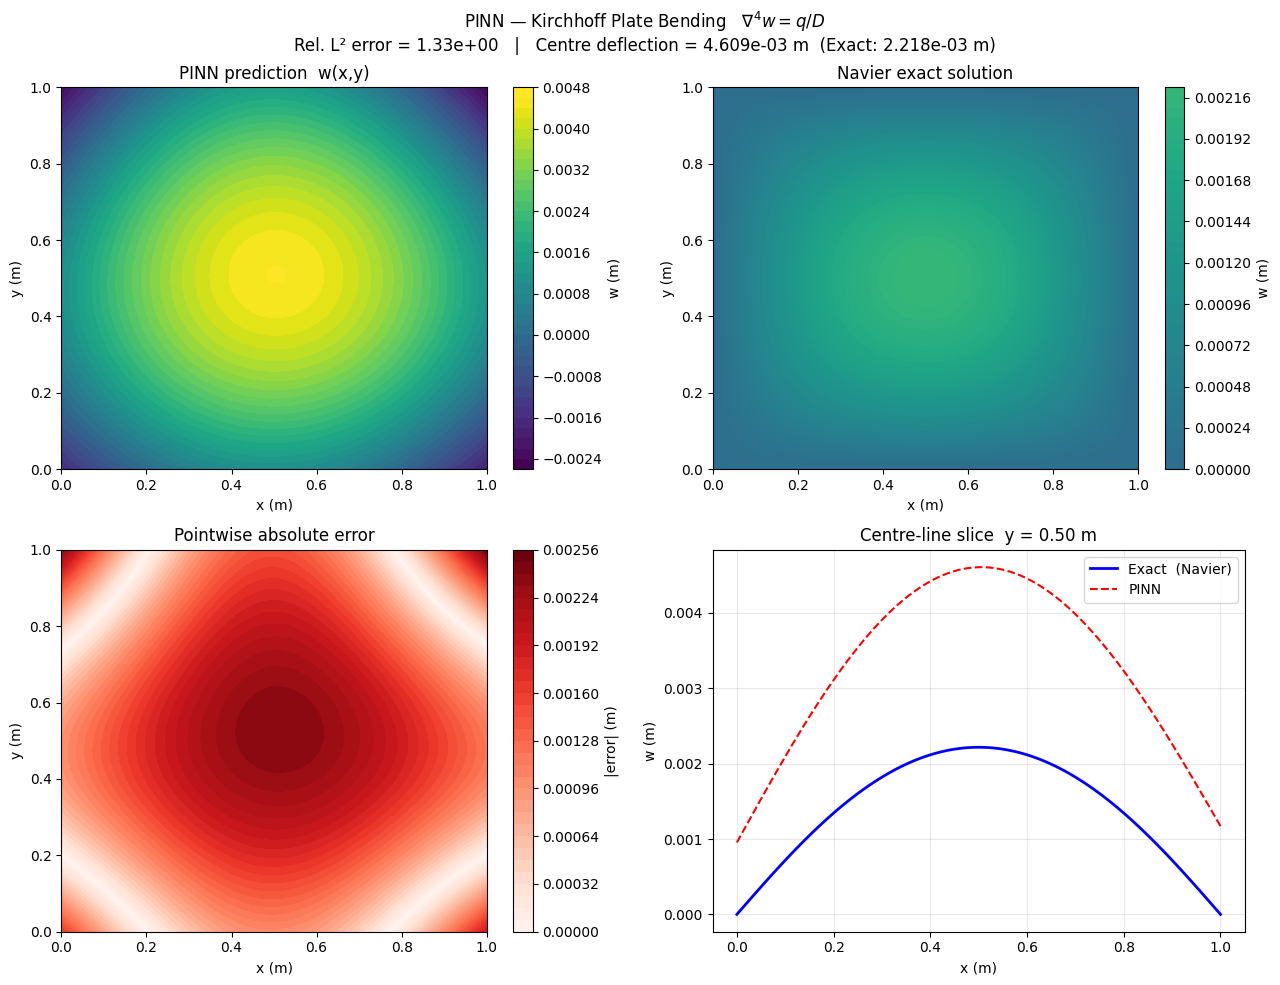

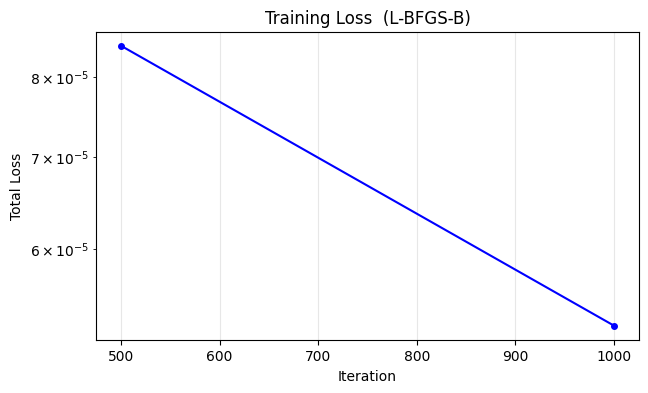

In [ ]:
"""
Physics-Informed Neural Network (PINN) for Kirchhoff Plate Bending
===================================================================
PDE:  ∇⁴w = q/D
      w_xxxx + 2*w_xxyy + w_yyyy = q(x,y) / D

Problem : Simply-supported square plate, uniform load q₀
Domain  : x ∈ [0, a],  y ∈ [0, b]

Boundary conditions (simply supported on all 4 edges):
  w    = 0  on all edges          (zero deflection)
  w_xx = 0  on x=0 and x=a       (zero moment Mx)
  w_yy = 0  on y=0 and y=b       (zero moment My)

Validation: Navier double-sine series (exact closed-form solution)

OPTIMIZATIONS APPLIED:
  1. @tf.function JIT compilation on train_step
  2. Moment BCs computed with 2-level tape instead of full 4-level plate_residual()
  3. Smaller collocation set (Nf=1000, Nb=50) used during Adam warm-up
  4. q0 and D passed as tf.constant to avoid graph retracing
  5. Timing check on first 5 steps to verify compilation is working

Install:
    pip install tensorflow numpy matplotlib scipy pyDOE
"""

import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pyDOE import lhs
from scipy.optimize import minimize


# ═════════════════════════════════════════════════════════════════════════════
# 1.  Neural Network Architecture
# ═════════════════════════════════════════════════════════════════════════════
class PINN(tf.keras.Model):
    """
    6 hidden layers × 40 neurons with tanh activation.
    Wider/deeper than Burgers because biharmonic operator is 4th-order.
    """

    def __init__(self, layers):
        super().__init__()
        self.hidden_layers = []
        for width in layers[1:-1]:
            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    width,
                    activation="tanh",
                    kernel_initializer="glorot_normal",
                    bias_initializer="zeros",
                )
            )
        self.out_layer = tf.keras.layers.Dense(
            layers[-1],
            kernel_initializer="glorot_normal",
            bias_initializer="zeros",
        )

    def call(self, x, y):
        inputs = tf.concat([x, y], axis=1)   # (N, 2)
        z = inputs
        for layer in self.hidden_layers:
            z = layer(z)
        return self.out_layer(z)             # (N, 1) — predicts w(x, y)


# ═════════════════════════════════════════════════════════════════════════════
# 2.  Physics Residual  (4-level tape — used only for interior points)
# ═════════════════════════════════════════════════════════════════════════════
def plate_residual(model, x_f, y_f, q0, D):
    """
    Computes the biharmonic residual:
        f = w_xxxx + 2*w_xxyy + w_yyyy  -  q/D

    Returns f, w_xx, w_yy
    NOTE: This is now called ONLY for interior collocation points.
          Boundary moment BCs use the cheaper get_second_derivs() below.
    """
    with tf.GradientTape(persistent=True) as tape4:
        tape4.watch([x_f, y_f])
        with tf.GradientTape(persistent=True) as tape3:
            tape3.watch([x_f, y_f])
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch([x_f, y_f])
                with tf.GradientTape(persistent=True) as tape1:
                    tape1.watch([x_f, y_f])
                    w = model(x_f, y_f)

                w_x  = tape1.gradient(w,   x_f)
                w_y  = tape1.gradient(w,   y_f)

            w_xx = tape2.gradient(w_x, x_f)
            w_yy = tape2.gradient(w_y, y_f)

        w_xxx = tape3.gradient(w_xx, x_f)
        w_xxy = tape3.gradient(w_xx, y_f)
        w_yyy = tape3.gradient(w_yy, y_f)

    w_xxxx = tape4.gradient(w_xxx, x_f)
    w_xxyy = tape4.gradient(w_xxy, y_f)
    w_yyyy = tape4.gradient(w_yyy, y_f)

    del tape1, tape2, tape3, tape4

    q = q0 * tf.ones_like(w)
    f = w_xxxx + 2.0 * w_xxyy + w_yyyy - q / D

    return f, w_xx, w_yy


# ═════════════════════════════════════════════════════════════════════════════
# FIX 1 — Cheap 2-level tape for boundary moment BCs
# ═════════════════════════════════════════════════════════════════════════════
def get_second_derivs(model, x_b, y_b):
    """
    Computes w_xx and w_yy on boundary points using only 2 levels of tape.
    This is ~4-5x cheaper than calling plate_residual() on boundary pts.
    Called 4 times (once per edge) instead of plate_residual() 4 times.
    """
    with tf.GradientTape(persistent=True) as t2:
        t2.watch([x_b, y_b])
        with tf.GradientTape(persistent=True) as t1:
            t1.watch([x_b, y_b])
            w = model(x_b, y_b)
        w_x = t1.gradient(w, x_b)
        w_y = t1.gradient(w, y_b)
        del t1
    w_xx = t2.gradient(w_x, x_b)
    w_yy = t2.gradient(w_y, y_b)
    del t2
    return w_xx, w_yy


# ═════════════════════════════════════════════════════════════════════════════
# 3.  Loss Function  (optimized — no redundant 4-level tape on boundary)
# ═════════════════════════════════════════════════════════════════════════════
def compute_loss(model,
                 x_f,  y_f,
                 x_x0, y_x0,
                 x_xa, y_xa,
                 x_y0, y_y0,
                 x_yb, y_yb,
                 q0, D,
                 lam_w=10.0, lam_m=10.0):
    """
    OPTIMIZED LOSS:
      - plate_residual() called ONCE (interior only) — 4-level tape × 1
      - get_second_derivs() called 4× (boundary edges) — 2-level tape × 4
      - Previously: plate_residual() was called 5× — 4-level tape × 5
      - Net saving: ~3-4× fewer tape operations per loss evaluation
    """

    # ── PDE residual loss (interior) ─────────────────────────────────────
    f, _, _ = plate_residual(model, x_f, y_f, q0, D)
    mse_f   = tf.reduce_mean(tf.square(f))

    # ── Deflection BC: w = 0 on all four edges ───────────────────────────
    w_x0 = model(x_x0, y_x0)
    w_xa = model(x_xa, y_xa)
    w_y0 = model(x_y0, y_y0)
    w_yb = model(x_yb, y_yb)
    mse_w = (tf.reduce_mean(tf.square(w_x0)) +
             tf.reduce_mean(tf.square(w_xa)) +
             tf.reduce_mean(tf.square(w_y0)) +
             tf.reduce_mean(tf.square(w_yb)))

    # ── Moment BC: cheap 2-level tape on boundary edges ──────────────────
    w_xx_x0, _        = get_second_derivs(model, x_x0, y_x0)
    w_xx_xa, _        = get_second_derivs(model, x_xa, y_xa)
    _,       w_yy_y0  = get_second_derivs(model, x_y0, y_y0)
    _,       w_yy_yb  = get_second_derivs(model, x_yb, y_yb)

    mse_m = (tf.reduce_mean(tf.square(w_xx_x0)) +
             tf.reduce_mean(tf.square(w_xx_xa)) +
             tf.reduce_mean(tf.square(w_yy_y0)) +
             tf.reduce_mean(tf.square(w_yy_yb)))

    total = mse_f + lam_w * mse_w + lam_m * mse_m
    return total, mse_f, mse_w, mse_m


# ═════════════════════════════════════════════════════════════════════════════
# FIX 2 — @tf.function JIT-compiled training step
# ═════════════════════════════════════════════════════════════════════════════
@tf.function
def train_step(model, optimizer,
               x_f,  y_f,
               x_x0, y_x0,
               x_xa, y_xa,
               x_y0, y_y0,
               x_yb, y_yb,
               q0, D):
    """
    @tf.function compiles this into a static TF graph.
    First call is slow (compilation), all subsequent calls run the
    compiled graph directly on GPU — typically 3-5x faster than eager mode.

    IMPORTANT: q0 and D must be tf.constant (not Python floats) to avoid
    retracing the graph on every call.
    """
    with tf.GradientTape() as tape:
        loss, mse_f, mse_w, mse_m = compute_loss(
            model,
            x_f,  y_f,
            x_x0, y_x0,
            x_xa, y_xa,
            x_y0, y_y0,
            x_yb, y_yb,
            q0, D
        )
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, mse_f, mse_w, mse_m


# ═════════════════════════════════════════════════════════════════════════════
# 4.  Training Data Generation
# ═════════════════════════════════════════════════════════════════════════════
def generate_training_data(a=1.0, b=1.0, Nf=10_000, Nb=200):
    """
    Generates interior collocation points (LHS) and boundary points.
    FIX 3: During Adam warm-up, call this with Nf=1000, Nb=50 for speed.
            During L-BFGS, use full Nf=10000, Nb=200.
    """
    lb = np.array([0.0, 0.0])
    ub = np.array([a,   b  ])

    X_f   = lb + (ub - lb) * lhs(2, Nf)

    s = np.random.uniform

    X_x0  = np.hstack([np.zeros((Nb, 1)),    s(0, b, (Nb, 1))])
    X_xa  = np.hstack([a * np.ones((Nb, 1)), s(0, b, (Nb, 1))])
    X_y0  = np.hstack([s(0, a, (Nb, 1)),     np.zeros((Nb, 1))])
    X_yb  = np.hstack([s(0, a, (Nb, 1)),     b * np.ones((Nb, 1))])

    return X_f, X_x0, X_xa, X_y0, X_yb


def to_tf(arr):
    return tf.constant(arr, dtype=tf.float32)


# ═════════════════════════════════════════════════════════════════════════════
# 5.  L-BFGS Trainer
# ═════════════════════════════════════════════════════════════════════════════
class LBFGSTrainer:
    """
    L-BFGS-B trainer using scipy.optimize.minimize.
    Uses the full collocation set (Nf=10000) for higher accuracy.
    Note: L-BFGS is inherently sequential so @tf.function gives less benefit
    here, but the fix to compute_loss() still reduces tape overhead.
    """

    def __init__(self, model,
                 x_f,  y_f,
                 x_x0, y_x0,
                 x_xa, y_xa,
                 x_y0, y_y0,
                 x_yb, y_yb,
                 q0, D):
        self.model = model
        self.x_f,  self.y_f   = x_f,  y_f
        self.x_x0, self.y_x0  = x_x0, y_x0
        self.x_xa, self.y_xa  = x_xa, y_xa
        self.x_y0, self.y_y0  = x_y0, y_y0
        self.x_yb, self.y_yb  = x_yb, y_yb
        self.q0, self.D       = q0, D

        self.iter         = 0
        self.loss_history = []
        self.shapes       = [v.shape for v in model.trainable_variables]
        self.n_params     = sum(np.prod(s) for s in self.shapes)
        print(f"Total trainable parameters: {self.n_params}")

    def _pack(self):
        return np.concatenate(
            [v.numpy().flatten() for v in self.model.trainable_variables]
        )

    def _unpack(self, flat):
        offset = 0
        for var, shape in zip(self.model.trainable_variables, self.shapes):
            size = np.prod(shape)
            var.assign(flat[offset: offset + size].reshape(shape))
            offset += size

    def loss_and_grad(self, flat_params):
        self._unpack(flat_params)

        with tf.GradientTape() as tape:
            loss, mse_f, mse_w, mse_m = compute_loss(
                self.model,
                self.x_f,  self.y_f,
                self.x_x0, self.y_x0,
                self.x_xa, self.y_xa,
                self.x_y0, self.y_y0,
                self.x_yb, self.y_yb,
                self.q0, self.D
            )

        grads     = tape.gradient(loss, self.model.trainable_variables)
        flat_grad = np.concatenate([g.numpy().flatten() for g in grads])

        loss_val  = loss.numpy().astype(np.float64)
        self.iter += 1

        if self.iter % 500 == 0:
            print(f"  Iter {self.iter:6d} | Loss {loss_val:.3e} | "
                  f"PDE {mse_f.numpy():.3e} | "
                  f"w-BC {mse_w.numpy():.3e} | "
                  f"M-BC {mse_m.numpy():.3e}")
            self.loss_history.append(loss_val)

        return loss_val, flat_grad.astype(np.float64)

    def train(self, max_iter=50_000):
        print("\nTraining with L-BFGS-B ...")
        x0     = self._pack().astype(np.float64)
        result = minimize(
            self.loss_and_grad, x0,
            method="L-BFGS-B", jac=True,
            options={"maxiter": max_iter, "maxfun": max_iter,
                     "ftol": 1e-12, "gtol": 1e-8, "disp": False},
        )
        self._unpack(result.x)
        print(f"Finished — {result.message}")
        print(f"Final loss: {result.fun:.3e}\n")
        return self.loss_history


# ═════════════════════════════════════════════════════════════════════════════
# 6.  Exact Navier Solution
# ═════════════════════════════════════════════════════════════════════════════
def navier_solution(X, Y, a, b, D, q0, n_terms=49):
    """
    Exact closed-form Navier series for a simply-supported plate.
    Converges very fast — 49 terms gives <0.01% error.
    """
    w = np.zeros_like(X, dtype=float)
    for m in range(1, n_terms + 1, 2):
        for n in range(1, n_terms + 1, 2):
            coeff = 16.0 * q0 / (np.pi**6 * D * m * n)
            denom = (m**2 / a**2 + n**2 / b**2) ** 2
            w += coeff / denom * \
                 np.sin(m * np.pi * X / a) * \
                 np.sin(n * np.pi * Y / b)
    return w


# ═════════════════════════════════════════════════════════════════════════════
# 7.  Evaluation & Plotting
# ═════════════════════════════════════════════════════════════════════════════
def evaluate_and_plot(model, loss_history, a, b, D, q0):
    N      = 100
    x_vals = np.linspace(0, a, N)
    y_vals = np.linspace(0, b, N)
    X, Y   = np.meshgrid(x_vals, y_vals)

    x_flat = to_tf(X.flatten()[:, None])
    y_flat = to_tf(Y.flatten()[:, None])

    w_pred  = model(x_flat, y_flat).numpy().reshape(N, N)
    w_exact = navier_solution(X, Y, a, b, D, q0)

    rel_l2    = (np.linalg.norm(w_pred - w_exact) /
                 np.linalg.norm(w_exact))
    w_c_pred  = w_pred[N//2, N//2]
    w_c_exact = w_exact[N//2, N//2]
    print(f"Relative L2 error        : {rel_l2:.3e}")
    print(f"Centre deflection — PINN : {w_c_pred:.4e} m")
    print(f"Centre deflection — Exact: {w_c_exact:.4e} m")

    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    fig.suptitle(
        r"PINN — Kirchhoff Plate Bending   $\nabla^4 w = q/D$"
        f"\nRel. L² error = {rel_l2:.2e}   |   "
        f"Centre deflection = {w_c_pred:.3e} m  (Exact: {w_c_exact:.3e} m)",
        fontsize=12
    )

    vmin = min(w_pred.min(), w_exact.min())
    vmax = max(w_pred.max(), w_exact.max())

    ax = axes[0, 0]
    im = ax.contourf(X, Y, w_pred,  levels=40, cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label="w (m)")
    ax.set_title("PINN prediction  w(x,y)")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    ax = axes[0, 1]
    im = ax.contourf(X, Y, w_exact, levels=40, cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax, label="w (m)")
    ax.set_title("Navier exact solution")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    ax = axes[1, 0]
    err_field = np.abs(w_pred - w_exact)
    im = ax.contourf(X, Y, err_field, levels=40, cmap="Reds")
    plt.colorbar(im, ax=ax, label="|error| (m)")
    ax.set_title("Pointwise absolute error")
    ax.set_xlabel("x (m)");  ax.set_ylabel("y (m)")

    ax = axes[1, 1]
    mid = N // 2
    ax.plot(x_vals, w_exact[mid, :], "b-",  lw=2,   label="Exact  (Navier)")
    ax.plot(x_vals, w_pred[mid, :],  "r--", lw=1.5, label="PINN")
    ax.set_title(f"Centre-line slice  y = {b/2:.2f} m")
    ax.set_xlabel("x (m)");  ax.set_ylabel("w (m)")
    ax.legend();  ax.grid(alpha=0.3)

    plt.tight_layout()
    out = "/content/pinn_plate_bending.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Plot saved → {out}")
    plt.show()

    if loss_history:
        fig2, ax2 = plt.subplots(figsize=(7, 4))
        ax2.semilogy(
            [i * 500 for i in range(1, len(loss_history) + 1)],
            loss_history, "b-o", ms=4
        )
        ax2.set_xlabel("Iteration");  ax2.set_ylabel("Total Loss")
        ax2.set_title("Training Loss  (L-BFGS-B)")
        ax2.grid(alpha=0.3)
        plt.savefig("/content/pinn_plate_loss.png", dpi=150, bbox_inches="tight")
        plt.show()


# ═════════════════════════════════════════════════════════════════════════════
# 8.  Entry Point
# ═════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":

    # ── Physical parameters ───────────────────────────────────────────────
    E    = 200e9
    nu   = 0.3
    h    = 0.01
    q0   = 1e4
    a, b = 1.0, 1.0
    D    = E * h**3 / (12.0 * (1.0 - nu**2))
    print(f"Flexural rigidity  D = {D:.4e}  N·m")

    # FIX 4 — Pass q0 and D as tf.constant so @tf.function never retraces
    q0_tf = tf.constant(q0, dtype=tf.float32)
    D_tf  = tf.constant(D,  dtype=tf.float32)

    # ── Build model ───────────────────────────────────────────────────────
    layers = [2] + [40] * 6 + [1]
    model  = PINN(layers)

    # ── FIX 3 — Small dataset for Adam warm-up ────────────────────────────
    print("\nGenerating warm-up data (small) ...")
    X_f_w, X_x0_w, X_xa_w, X_y0_w, X_yb_w = generate_training_data(
        a=a, b=b, Nf=1000, Nb=50      # much smaller than full set
    )
    x_f_w  = to_tf(X_f_w[:,  0:1]);  y_f_w  = to_tf(X_f_w[:,  1:2])
    x_x0_w = to_tf(X_x0_w[:, 0:1]); y_x0_w = to_tf(X_x0_w[:, 1:2])
    x_xa_w = to_tf(X_xa_w[:, 0:1]); y_xa_w = to_tf(X_xa_w[:, 1:2])
    x_y0_w = to_tf(X_y0_w[:, 0:1]); y_y0_w = to_tf(X_y0_w[:, 1:2])
    x_yb_w = to_tf(X_yb_w[:, 0:1]); y_yb_w = to_tf(X_yb_w[:, 1:2])

    # ── Verify @tf.function is compiling correctly (timing check) ─────────
    optimizer_adam = tf.keras.optimizers.Adam(learning_rate=1e-3)
    print("\nVerifying @tf.function compilation (first step = slow, rest = fast):")
    for step in range(5):
        t = time.time()
        loss, mse_f, mse_w, mse_m = train_step(
            model, optimizer_adam,
            x_f_w,  y_f_w,
            x_x0_w, y_x0_w,
            x_xa_w, y_xa_w,
            x_y0_w, y_y0_w,
            x_yb_w, y_yb_w,
            q0_tf, D_tf
        )
        elapsed = time.time() - t
        print(f"  Step {step}: {elapsed:.2f}s  | Loss {loss.numpy():.3e}")
    print("  ✓ If steps 1-4 are <0.5s, compilation is working correctly.\n")

    # ── Adam warm-up — fast, small dataset, compiled graph ────────────────
    print("Adam warm-up (1000 steps, small dataset) ...")
    t_warmup = time.time()
    for step in range(1000):
        loss, mse_f, mse_w, mse_m = train_step(
            model, optimizer_adam,
            x_f_w,  y_f_w,
            x_x0_w, y_x0_w,
            x_xa_w, y_xa_w,
            x_y0_w, y_y0_w,
            x_yb_w, y_yb_w,
            q0_tf, D_tf
        )
        if (step + 1) % 200 == 0:
            print(f"  Adam step {step+1:4d} | Loss {loss.numpy():.3e} | "
                  f"PDE {mse_f.numpy():.3e} | "
                  f"w-BC {mse_w.numpy():.3e} | "
                  f"M-BC {mse_m.numpy():.3e}")
    print(f"  Adam warm-up done in {time.time() - t_warmup:.1f}s\n")

    # ── Full dataset for L-BFGS ────────────────────────────────────────────
    print("Generating full training data ...")
    X_f, X_x0, X_xa, X_y0, X_yb = generate_training_data(
        a=a, b=b, Nf=10_000, Nb=200
    )
    x_f   = to_tf(X_f[:,  0:1]);  y_f   = to_tf(X_f[:,  1:2])
    x_x0  = to_tf(X_x0[:, 0:1]); y_x0  = to_tf(X_x0[:, 1:2])
    x_xa  = to_tf(X_xa[:, 0:1]); y_xa  = to_tf(X_xa[:, 1:2])
    x_y0  = to_tf(X_y0[:, 0:1]); y_y0  = to_tf(X_y0[:, 1:2])
    x_yb  = to_tf(X_yb[:, 0:1]); y_yb  = to_tf(X_yb[:, 1:2])

    # ── L-BFGS optimisation on full dataset ───────────────────────────────
    trainer = LBFGSTrainer(
        model,
        x_f,  y_f,
        x_x0, y_x0,
        x_xa, y_xa,
        x_y0, y_y0,
        x_yb, y_yb,
        q0_tf, D_tf
    )
    loss_history = trainer.train(max_iter=6_000)

    # ── Evaluate & plot ────────────────────────────────────────────────────
    evaluate_and_plot(model, loss_history, a, b, D, q0)